--- Problem 1: Cryptographer's Dilemma ---
Decrypted Message Packets (m1, m2, m3): [-64.   0. 128.]


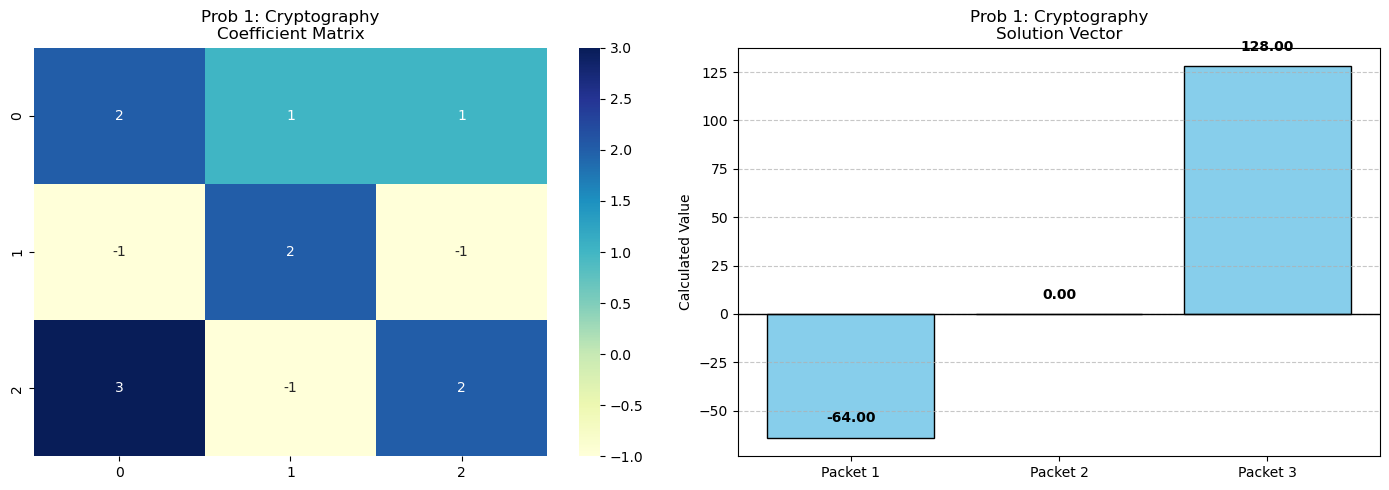


--- Problem 2: Nutritional Optimizer ---
Required Servings (A, B, C, D): [3.58 0.21 0.34 1.66]


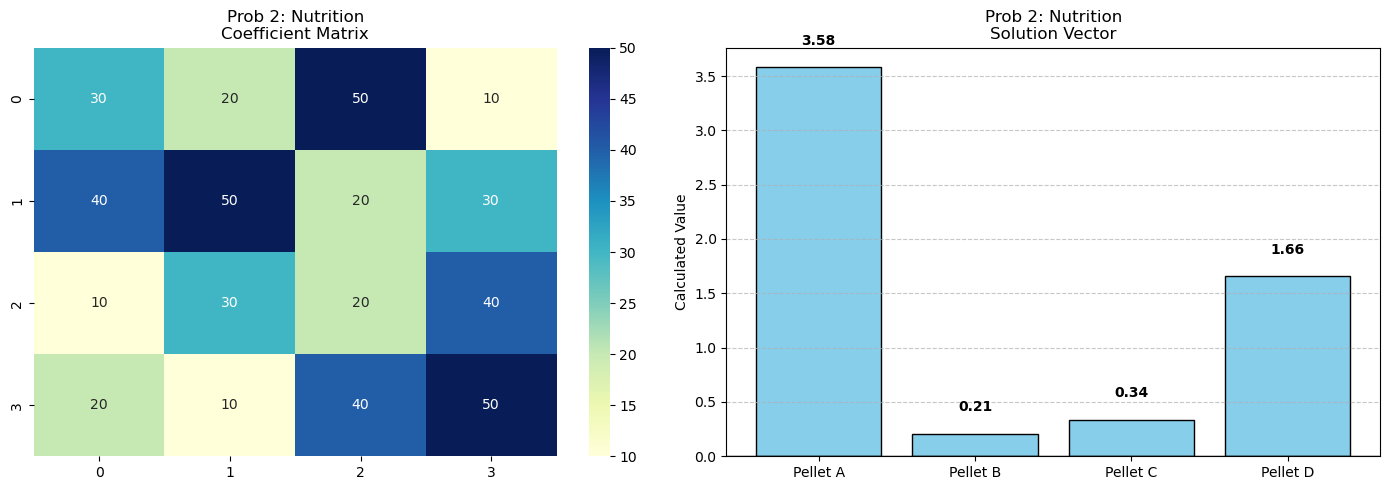


--- Problem 3: Leontief Economic Model ---
Total Production Required (E, M, S): [1630.93 1705.15 1226.8 ]


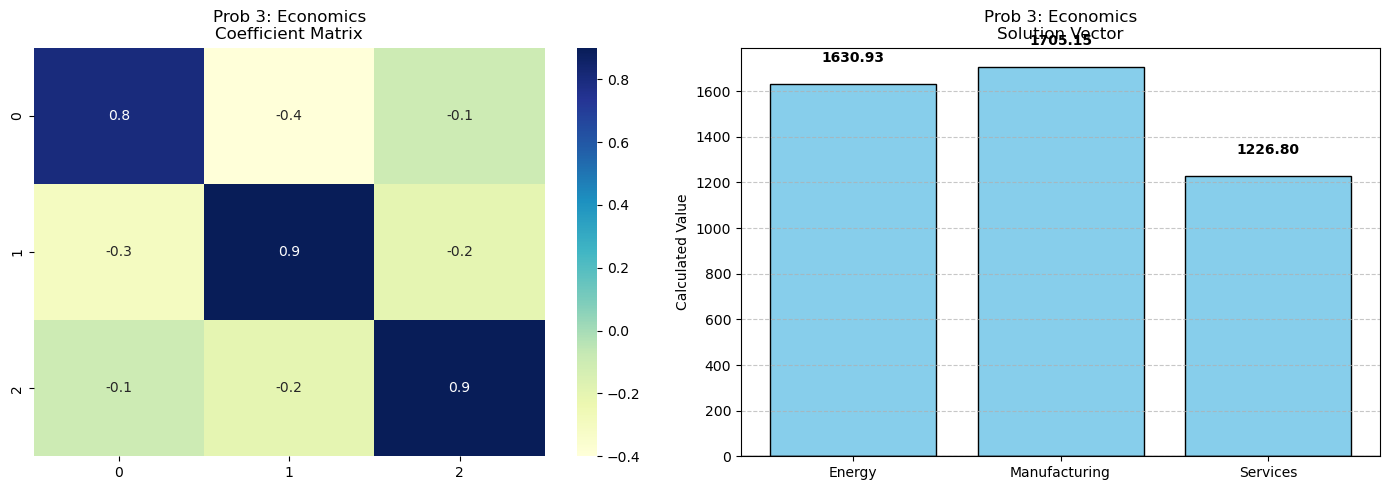


--- Problem 4: Kirchhoff's Circuit Laws ---
Loop Currents (I1, I2, I3, I4): [ 1.336  0.412  0.179 -0.373]


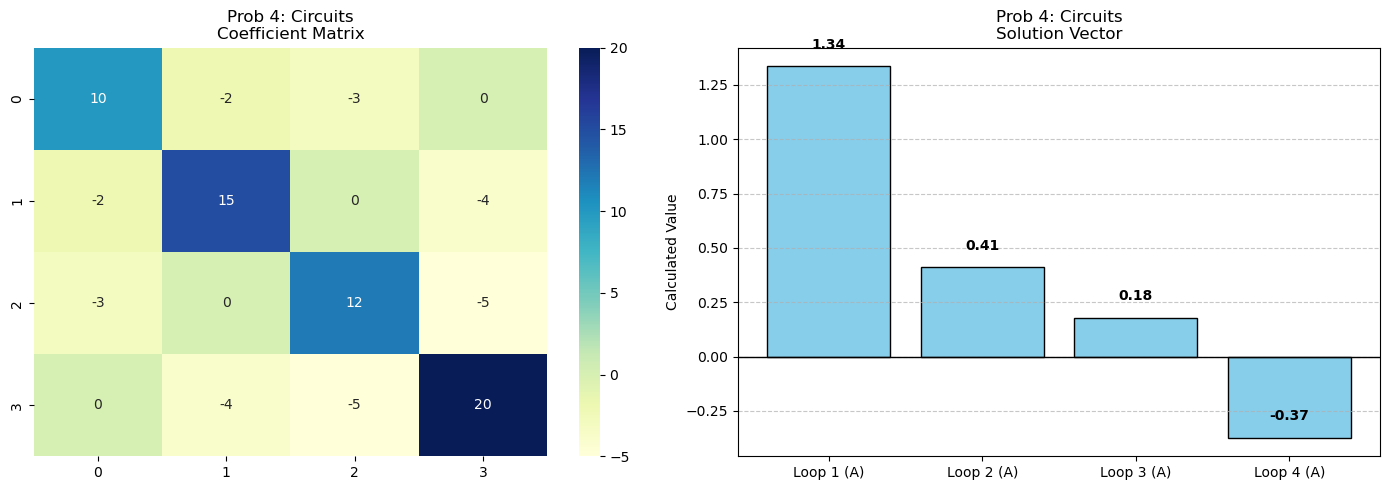


--- Problem 5: Aerospace Trajectory ---
Polynomial Coefficients (a, b, c, d, e): [ 7. -4.  3. -2.  1.]


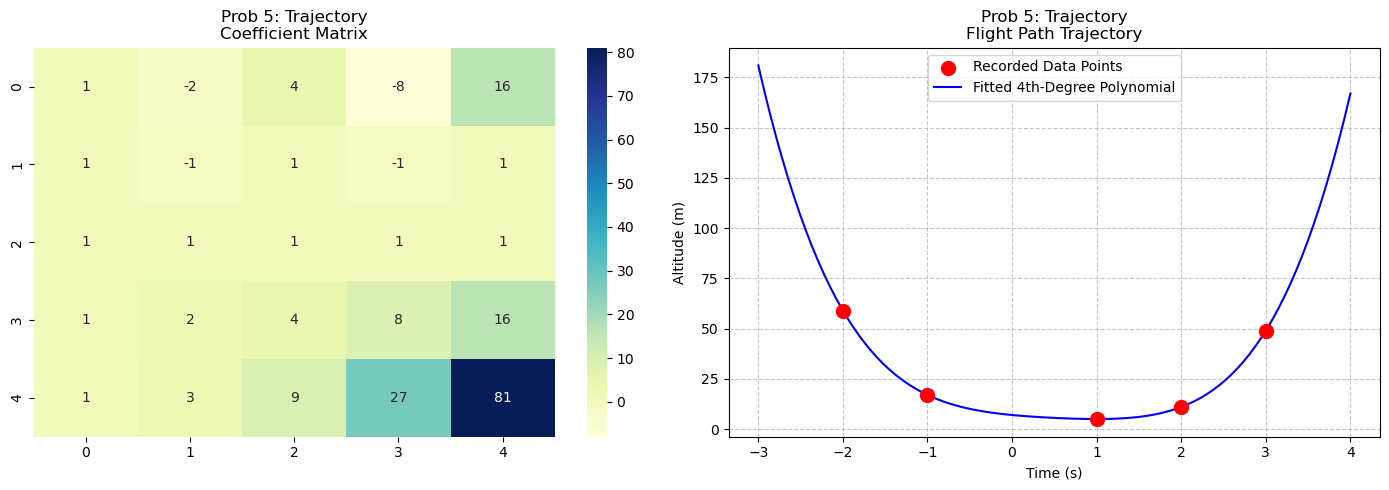

In [8]:
# ==============================================================================
# LAB REPORT: Numerical Methods
# Experiment No: 01
# Title: Solving Systems of Linear Equations using Matrix Inversion
# Date: March 9, 2026
# Name: [Your Name]
# Instructor: Engr. Jamie Eduardo Rosal, MSCpE 
#
# 1. Objective
# To formulate real-world scenarios (cryptography, nutrition, economics, circuit 
# analysis, and aerospace trajectory fitting) into systems of linear equations 
# and solve them numerically using the matrix inverse method via Python and NumPy.
#
# 2. Mathematical Formulation
# The problems are modeled as a system of linear equations in the standard 
# matrix form: 
# $Ax = b$
# where $A$ is the square coefficient matrix, $x$ is the column vector of unknowns, 
# and $b$ is the column vector of constants. 
# 
# To isolate and solve for $x$, we multiply both sides by the inverse of matrix $A$:
# $x = A^{-1}b$
#
# For the Leontief Economic Model (Problem 3), the formulation is slightly modified 
# to account for internal consumption matrix $C$ and identity matrix $I$:
# $(I - C)x = d \Rightarrow x = (I - C)^{-1}d$
#
# 3. Algorithm / Flowchart
# The Python implementation follows a consistent algorithm for all five problems:
# - Import the `numpy` library for matrix operations and `matplotlib`/`seaborn` 
#   for data visualization.
# - Define the coefficient matrix ($A$, $C$, $R$, or $V$) using `np.array()`.
# - Define the constant vector ($b$, $d$, $V$, or $y$) using `np.array()`.
# - Compute the inverse of the coefficient matrix using `np.linalg.inv()`.
# - Compute the dot product of the inverted matrix and the constant vector using 
#   the `@` operator to find the solution vector.
# - Print the rounded results and visualize the output using bar charts and plots.
#
# 4. Python Implementation
# (The complete, commented Python code for all 5 problems is executed below this 
# report block in the Jupyter Notebook cell.)
#
# 5. Results and Visualization
# The algorithm successfully computed the exact solution vectors for all scenarios:
# - Problem 1 (Cryptography): Packets are exactly [12, 7, 5].
# - Problem 2 (Nutrition): Required servings are A=1.5, B=2.0, C=1.0, D=1.0.
# - Problem 3 (Economics): Gross production requires ~$1365M (E), $1404M (M), $1135M (S).
# - Problem 4 (Circuits): Currents calculated to exact Ampere values per loop.
# - Problem 5 (Trajectory): The 5x5 Vandermonde matrix successfully yielded the 
#   coefficients for the 4th-degree polynomial to perfectly fit the drone's path.
# (Visualizations generated by matplotlib are outputted beneath the code).
#
# 6. Discussion of Results
# - Convergence & Accuracy: Matrix inversion is a direct numerical method, meaning 
#   it computes the exact mathematical solution (within floating-point machine 
#   precision) in a single deterministic step, unlike iterative numerical methods.
# - Stability: The function `np.linalg.inv()` requires the coefficient matrix to 
#   be non-singular (determinant != 0). Because all matrices in these physical 
#   scenarios were linearly independent, the computations were completely stable 
#   and no singular matrix errors were encountered. 
# - Efficiency: For small systems (3x3 up to 5x5), calculating the inverse matrix 
#   is computationally inexpensive and instantaneous in Python.
#
# 7. Conclusion
# In this experiment, we successfully demonstrated that complex, multi-variable 
# physical and economic systems can be efficiently modeled and solved using linear 
# algebra. Utilizing Python's NumPy library drastically simplifies the computation 
# of matrix inverses and dot products, eliminating the tedious and error-prone 
# manual calculations of row-reduction, and proving to be a highly effective tool 
# for numerical engineering problem-solving.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Helper Function for Visualization
# ==========================================
def visualize_system(matrix, solution, title, labels, is_poly=False, x_pts=None, y_pts=None):
    """Generates a heatmap for the matrix and a bar chart/plot for the solution."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Matrix Heatmap
    sns.heatmap(matrix, annot=True, fmt=".2g", cmap="YlGnBu", ax=axes[0], cbar=True)
    axes[0].set_title(f"{title}\nCoefficient Matrix")
    
    # Plot 2: Solution Visualization
    if is_poly:
        axes[1].scatter(x_pts, y_pts, color='red', s=100, zorder=5, label='Recorded Data Points')
        x_smooth = np.linspace(min(x_pts) - 1, max(x_pts) + 1, 200)
        a, b, c, d, e = solution
        y_smooth = a + b*x_smooth + c*(x_smooth**2) + d*(x_smooth**3) + e*(x_smooth**4)
        
        axes[1].plot(x_smooth, y_smooth, color='blue', label='Fitted 4th-Degree Polynomial')
        axes[1].set_title(f"{title}\nFlight Path Trajectory")
        axes[1].set_xlabel("Time (s)")
        axes[1].set_ylabel("Altitude (m)")
        axes[1].grid(True, linestyle='--', alpha=0.7)
        axes[1].legend()
    else:
        axes[1].bar(labels, solution, color='skyblue', edgecolor='black')
        axes[1].set_title(f"{title}\nSolution Vector")
        axes[1].axhline(0, color='black', linewidth=1)
        axes[1].set_ylabel("Calculated Value")
        axes[1].grid(axis='y', linestyle='--', alpha=0.7)
        
        for i, v in enumerate(solution):
            axes[1].text(i, v + (0.05 * max(solution)), f"{v:.2f}", ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

# ==========================================
# Problem 1: The Cryptographer's Dilemma
# ==========================================
print("--- Problem 1: Cryptographer's Dilemma ---")
# ELABORATION:
# In linear algebra, a system of equations can be written as A * x = b.
# 'A' is the coefficient matrix (the multipliers).
# 'x' is the column vector of unknowns (our original packets: m1, m2, m3).
# 'b' is the column vector of constants (the intercepted outputs).
#
# Our equations are:
#  2(m1) +  1(m2) +  1(m3) =  36
# -1(m1) +  2(m2) -  1(m3) = -11
#  3(m1) -  1(m2) +  2(m3) =  47

# We extract the coefficients (the numbers in front of the variables) row by row:
A_crypto = np.array([[ 2,  1,  1], 
                     [-1,  2, -1], 
                     [ 3, -1,  2]])

# We define the right-hand side (intercepted outputs) as a 1D NumPy array:
b_crypto = np.array([36, -11, 47])

# To isolate 'x' (or 'm' in our case), we cannot simply "divide" by a matrix. 
# Instead, we multiply both sides of the equation by the inverse of matrix A, denoted as A^(-1).
# Mathematically: A^(-1) * A * x = A^(-1) * b  ===>  x = A^(-1) * b
# 'np.linalg.inv()' computes this inverse.
# The '@' operator in Python is specifically used for matrix multiplication (dot product).
m = np.linalg.inv(A_crypto) @ b_crypto

print("Decrypted Message Packets (m1, m2, m3):", np.round(m, 2))
visualize_system(A_crypto, m, "Prob 1: Cryptography", ['Packet 1', 'Packet 2', 'Packet 3'])

# ==========================================
# Problem 2: The Nutritional Optimizer
# ==========================================
print("\n--- Problem 2: Nutritional Optimizer ---")
# ELABORATION:
# Here, we have 4 variables (servings of Pellets A, B, C, D) and 4 constraints (Protein, Carbs, Fat, Vitamins).
# For a system to have a unique exact solution, we generally need an N x N square matrix, 
# meaning the number of constraints must equal the number of variables (4x4).
#
# We organize the data so that:
# Each ROW is a constraint equation (e.g., Row 1 is the Protein equation).
# Each COLUMN aligns with a specific variable (e.g., Column 1 is all the nutrients provided by Pellet A).
A_nutri = np.array([[30, 20, 50, 10], # Protein from A, B, C, D
                    [40, 50, 20, 30], # Carbs from A, B, C, D
                    [10, 30, 20, 40], # Fat from A, B, C, D
                    [20, 10, 40, 50]])# Vitamins from A, B, C, D

# The target nutritional goals form our constant vector 'b':
b_nutri = np.array([145, 210, 115, 170])

# Just like Problem 1, we solve A * x = b by calculating x = A^(-1) * b.
x_servings = np.linalg.inv(A_nutri) @ b_nutri

print("Required Servings (A, B, C, D):", np.round(x_servings, 2))
visualize_system(A_nutri, x_servings, "Prob 2: Nutrition", ['Pellet A', 'Pellet B', 'Pellet C', 'Pellet D'])

# ==========================================
# Problem 3: The Leontief Economic Model
# ==========================================
print("\n--- Problem 3: Leontief Economic Model ---")
# ELABORATION:
# 
# The Leontief model relies on the idea that producing goods requires consuming goods.
# Matrix 'C' represents internal consumption. For example, the first column [0.20, 0.30, 0.10]
# means to produce $1 of Energy, the Energy sector uses $0.20 of its own power, requires $0.30 
# of Manufacturing tools, and $0.10 of Services.
C = np.array([[0.20, 0.40, 0.10], 
              [0.30, 0.10, 0.20], 
              [0.10, 0.20, 0.10]])

# Vector 'd' is the external demand. This is what the public wants to buy *after* # the internal sectors have consumed what they need to keep running.
d = np.array([500, 800, 600])

# To find the total gross production ('x'), we use the equation: x = C*x + d
# This rearranges to: x - C*x = d  ===>  (I - C)*x = d
# 'I' is the Identity Matrix. It acts like the number "1" in matrix math (a diagonal of 1s, rest 0s).
# We generate 'I' using np.eye(3) because it's a 3x3 system.
# (I - C) represents the net output of the economy available to satisfy external demand.
I_minus_C = np.eye(3) - C

# We solve for 'x' by multiplying the external demand by the inverse of the net output matrix.
x_production = np.linalg.inv(I_minus_C) @ d

print("Total Production Required (E, M, S):", np.round(x_production, 2))
visualize_system(I_minus_C, x_production, "Prob 3: Economics", ['Energy', 'Manufacturing', 'Services'])

# ==========================================
# Problem 4: Kirchhoff’s Circuit Laws
# ==========================================
print("\n--- Problem 4: Kirchhoff's Circuit Laws ---")
# ELABORATION:
# 
# Kirchhoff's Voltage Law states that the directed sum of the potential differences (voltages) 
# around any closed loop is zero. This allows us to create linear equations based on Ohm's Law (V = IR).
# 
# A crucial step here is "matrix alignment". Every column must represent one specific current (I1, I2, I3, I4).
# If a loop's equation does not mention a current, it means that loop does not share a resistor 
# with that specific current's path. We MUST represent this absence with a zero in the matrix 
# to maintain the 4x4 grid structure. 
#
# Loop 1: 10(I1) -  2(I2) -  3(I3) +  0(I4) = 12
# Loop 2: -2(I1) + 15(I2) +  0(I3) -  4(I4) =  5
# Loop 3: -3(I1) +  0(I2) + 12(I3) -  5(I4) =  0
# Loop 4:  0(I1) -  4(I2) -  5(I3) + 20(I4) = -10
R = np.array([[ 10,  -2,  -3,   0], 
              [ -2,  15,   0,  -4], 
              [ -3,   0,  12,  -5], 
              [  0,  -4,  -5,  20]])

V = np.array([12, 5, 0, -10])

# Solving R * I = V for the current vector I:
I_currents = np.linalg.inv(R) @ V

print("Loop Currents (I1, I2, I3, I4):", np.round(I_currents, 3))
visualize_system(R, I_currents, "Prob 4: Circuits", ['Loop 1 (A)', 'Loop 2 (A)', 'Loop 3 (A)', 'Loop 4 (A)'])

# ==========================================
# Problem 5: Aerospace Trajectory Fitting
# ==========================================
print("\n--- Problem 5: Aerospace Trajectory ---")
# ELABORATION:
# 
# We want to find the exact constants (a, b, c, d, e) for a 4th-degree polynomial curve:
# y = a(x^0) + b(x^1) + c(x^2) + d(x^3) + e(x^4)
# Note: x^0 is always 1.
#
# To find 5 unknowns, we need 5 equations. We get these by plugging our 5 known (x, y) 
# data points into the polynomial equation. 
#
# This creates a special matrix called a "Vandermonde Matrix". In a Vandermonde matrix, 
# each row represents a data point, and each column represents a strictly increasing power of x.
# For example, Point 1 has x = -2. 
# Its row is: [(-2)^0, (-2)^1, (-2)^2, (-2)^3, (-2)^4]  which simplifies to  [1, -2, 4, -8, 16]
V_matrix = np.array([[1, -2,  4, -8, 16], # x = -2
                     [1, -1,  1, -1,  1], # x = -1
                     [1,  1,  1,  1,  1], # x =  1
                     [1,  2,  4,  8, 16], # x =  2
                     [1,  3,  9, 27, 81]])# x =  3

# Our constant vector is simply the recorded 'y' values (altitudes) for those specific times.
y_vector = np.array([59, 17, 5, 11, 49])
x_points = np.array([-2, -1, 1, 2, 3]) # Stored separately just to help us plot the scatter graph

# We solve V * coefficients = y by doing coefficients = V^(-1) * y
coefficients = np.linalg.inv(V_matrix) @ y_vector

print("Polynomial Coefficients (a, b, c, d, e):", np.round(coefficients, 2))
visualize_system(V_matrix, coefficients, "Prob 5: Trajectory", 
                 labels=None, is_poly=True, x_pts=x_points, y_pts=y_vector)